### xgb_ranker with synopses

This is a modification of the models made in the ```xgb_ranker.ipynb``` notebook with the addition of encoded synopses.

In [46]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import numpy as np
import csv
import pandas as pd
from itertools import islice
import json
import missingno as msno
import matplotlib.pyplot as plt
import sklearn
import sys

sys.path.append("../scripts")

In [3]:
books_tt = pd.read_csv('../data/books_engineered_train.csv')
books_tt.head()

,Unnamed: 0.1,Unnamed: 0,title,author,release_year,first_publisher,tags,hugo,locus,month_of_publication,...,tag_urban,tag_urban fantasi,tag_vampir,tag_video gam,tag_war,tag_weak character develop,tag_weird,tag_werewolf,tag_ya,tag_zombi
0,4548,4548,The Hawkstone,Jay Williams,1971,Other,[''],False,False,10,...,0,0,0,0,0,0,0,0,0,0
1,4549,4549,"Barnabas, Quentin and Dr. Jekyll's Son",Marilyn Ross,1971,Other,NaN,False,False,04,...,0,0,0,0,0,0,0,0,0,0
2,4550,4550,Swap Around the Ouija,John Dexter,1971,Other,NaN,False,False,Unknown,...,0,0,0,0,0,0,0,0,0,0
3,4551,4551,The Sun Grows Cold,Howard Berk,1971,dell,['apocalyps'],False,False,01,...,0,0,0,0,0,0,0,0,0,0
4,4552,4552,The Seal-Singing,Rosemary Harris,1971,Other,['anim'],False,False,Unknown,...,0,0,0,0,0,0,0,0,0,0


In [4]:
books_tt.release_year.unique()

array([1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981,
       1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992,
       1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
       2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014])

In [5]:
books = pd.read_csv('../data/data_with_author_and_awards.csv',
dtype = {
    'isbn' : 'str', # do this explicitly to avoide getting a warning by the interpreter
    'author_birthyear' : 'Int64', # we have to explicitly do this to avoid pandas implicitly casting as float
    'title_id' : 'Int64'
},
)

books = books[(1971 <= books.release_year) & (books.release_year <= 2014)]

In [6]:
books_tt['book_synopsis'] = books.book_synopsis

/tmp/ipykernel_9950/230166750.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  books_tt['book_synopsis'] = books.book_synopsis


In [7]:
books_tt.book_synopsis = books_tt.book_synopsis.apply(lambda x : '' if pd.isnull(x) else x)

In [8]:
books_tt

,Unnamed: 0.1,Unnamed: 0,title,author,release_year,first_publisher,tags,hugo,locus,month_of_publication,...,tag_urban fantasi,tag_vampir,tag_video gam,tag_war,tag_weak character develop,tag_weird,tag_werewolf,tag_ya,tag_zombi,book_synopsis
0,4548,4548,The Hawkstone,Jay Williams,1971,Other,[''],False,False,10,...,0,0,0,0,0,0,0,0,0,
1,4549,4549,"Barnabas, Quentin and Dr. Jekyll's Son",Marilyn Ross,1971,Other,NaN,False,False,04,...,0,0,0,0,0,0,0,0,0,
2,4550,4550,Swap Around the Ouija,John Dexter,1971,Other,NaN,False,False,Unknown,...,0,0,0,0,0,0,0,0,0,
3,4551,4551,The Sun Grows Cold,Howard Berk,1971,dell,['apocalyps'],False,False,01,...,0,0,0,0,0,0,0,0,0,
4,4552,4552,The Seal-Singing,Rosemary Harris,1971,Other,['anim'],False,False,Unknown,...,0,0,0,0,0,0,0,0,0,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75103,79651,79651,Path of the Dead,Timothy Baker,2014,Other,"['thriller', 'fantasi']",False,False,05,...,0,0,0,0,0,0,0,0,0,
75104,79652,79652,Ure Infectus,Caleb Wachter,2014,Other,[''],False,False,09,...,0,0,0,0,0,0,0,0,0,
75105,79653,79653,Exile,Chris Ward,2014,Other,NaN,False,False,01,...,0,0,0,0,0,0,0,0,0,
75106,79654,79654,Superheroes Anonymous,Lexie Dunne,2014,Other,['superhero'],False,False,11,...,0,0,0,0,0,0,0,0,0,


In [9]:
sys.path.append('../../')
import tagging_system.automate_tagging as at

In [10]:
transformer = at.load_transformer()

books_tt = at.encode_books(books_tt, transformer)

/home/tiger/Documents/erdos/summer26-nomination-worthy-books/CLEAN-REPO/models/../../tagging_system/automate_tagging.py:604: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  books['encoded_synopsis'] = books.book_synopsis.apply(transformer.encode)


In [11]:
books_tt

,Unnamed: 0.1,Unnamed: 0,title,author,release_year,first_publisher,tags,hugo,locus,month_of_publication,...,tag_vampir,tag_video gam,tag_war,tag_weak character develop,tag_weird,tag_werewolf,tag_ya,tag_zombi,book_synopsis,encoded_synopsis
25,4573,4573,Destiny Doll,Clifford D. Simak,1971,Other,['sf'],False,False,06,...,0,0,0,0,0,0,0,0,,"[-0.1188384, 0.048298758, -0.0025481568, -0.01..."
74,4622,4622,Arrive at Easterwine: The Autobiography of a K...,R. A. Lafferty,1971,ballantinebooks,"['american', 'fantasi', 'sf']",False,False,06,...,0,0,0,0,0,0,0,0,,"[-0.1188384, 0.048298758, -0.0025481568, -0.01..."
149,4697,4697,The Byworlder,Poul Anderson,1971,baenbooks,['sf'],False,True,09,...,0,0,0,0,0,0,0,0,,"[-0.1188384, 0.048298758, -0.0025481568, -0.01..."
161,4709,4709,The Goat Without Horns,Thomas Burnett Swann,1971,ballantinebooks,[''],False,False,10,...,0,0,0,0,0,0,0,0,,"[-0.1188384, 0.048298758, -0.0025481568, -0.01..."
189,4737,4737,... And All the Stars a Stage,James Blish,1971,Other,"['space travel', 'apocalyps', 'sf']",False,False,07,...,0,0,0,0,0,0,0,0,,"[-0.1188384, 0.048298758, -0.0025481568, -0.01..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74798,79346,79346,A Plague of Unicorns,Jane Yolen,2014,Other,"['ya', 'fantasi']",False,False,12,...,0,0,0,0,0,0,1,0,,"[-0.1188384, 0.048298758, -0.0025481568, -0.01..."
74810,79358,79358,The Fatal Tree,Stephen R. Lawhead,2014,Other,"['adventur', 'alternate histori', 'time travel...",False,False,11,...,0,0,0,0,0,0,0,0,In an America where parenting is regulated by ...,"[-0.07610254, -0.047540735, -0.05690084, -0.00..."
74847,79395,79395,Waistcoats & Weaponry,Gail Carriger,2014,"little,brown","['strong character develop', 'relax', 'sf', 'f...",False,False,11,...,0,0,0,0,0,0,1,0,,"[-0.1188384, 0.048298758, -0.0025481568, -0.01..."
74857,79405,79405,Interstellar: The Official Movie Novelization,Greg Keyes,2014,titanbooks,['sf'],False,False,11,...,0,0,0,0,0,0,0,0,,"[-0.1188384, 0.048298758, -0.0025481568, -0.01..."


In [41]:
%conda install -c conda-forge pattern

2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /home/tiger/anaconda3/envs/erdos_ds_environment

  added / updated specs:
    - pattern


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    annotated-doc-0.0.4        |     pyhcf101f3_0          14 KB  conda-forge
    backports-1.0              |     pyhd8ed1ab_5           7 KB  conda-forge
    backports.tarfile-1.2.0    |     pyhcf101f3_2          35 KB  conda-forge
    cherrypy-18.10.0           |  py312h7900ff3_2         591 KB  conda-forge
    colorama-0.4.6             |     pyhd8ed1ab_1          26 KB  conda-forge
    cryptography-49.0.0   

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
sys.path.append("../scripts")
from feature_engineering.feature_engineering import tag_dataframe
from custom_yearly_scalers import YearByYearStandardScaler, YearlyGenreTagScaler, YearlyPastNomineeSimilarityScaler
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer


from sklearn.neighbors import KNeighborsClassifier


knn = KNeighborsClassifier(n_neighbors = 2, weights = 'distance', n_jobs = -1) # parameters discovered in another notebook

numerical_features = ["Total_Awards_Previously", "Author_Age_at_Publication", "author_num_books", "years_since_last_nomination", "publisher_historical_nominations", "publisher_cohort_size"]
categorical_features = ["first_publisher", "month_of_publication"]
mlb_features = ["tags"]
bool_features = ["new_author"]
synopsis = ['encoded_synopsis']

# for each categorical feature, create one-hot encoding
categorical_pipeline = Pipeline(
    steps=[
        ('solve_nans', SimpleImputer(fill_value='Unknown', strategy='constant')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ] 
)

# numerical features: z-score normalization with the rest of the year.
# turn bool features to int
# calculate similarities
feature_preprocessing = ColumnTransformer(
    transformers=[
        ('numerical_scaling', YearByYearStandardScaler(year_column='release_year', scale_columns=numerical_features), numerical_features + ['release_year']),
        ('bool_to_int', FunctionTransformer(lambda x: x.astype(int), feature_names_out='one-to-one'), bool_features),
        ('onehot', categorical_pipeline, categorical_features),
    ('tag_similarity', YearlyGenreTagScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year']) ,
    ('nominee_,similarity', YearlyPastNomineeSimilarityScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year']),
    ('synopsis', "passthrough", ['knn_pred'])
    ],
)

We shall use **walk-forward nested time series cross-validation**.

In [14]:
from walkforward_cv import walk_forward

def walk_forward(data, initial_size=5, step=1):
    # data is a data
    years = data['release_year'].unique()
    num_years = len(years)
    splits = []

    for i in range(initial_size, num_years - step + 1):
        # print(num_years - initial_size - step + 1)
        data_start = 0
        data_end = i
        val_start = data_end
        val_end = val_start + step

        window = data[data['release_year'].isin(years[data_start:data_end])]
        val = data[data['release_year'].isin(years[val_start:val_end])]

        splits.append((window, val))

    return splits


windows = walk_forward(books_tt)


In [10]:
print(len(windows))

39


In [43]:
features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features + ['knn_pred']

import xgboost as xgb

model =  Pipeline(steps=[
        ('preprocess', feature_preprocessing),
        ('xgb_rank', xgb.XGBRanker(
    tree_method="hist",
    objective="rank:ndcg",
    eval_metric="ndcg@60", # because each year has < 60 nominees, we care most about ranking those.
    lambdarank_pair_method="topk",

    lambdarank_num_pair_per_sample=60, 
    
    max_depth=4,                       
    learning_rate=0.05,
    n_estimators=300,                  
    colsample_bytree=0.7,              
    subsample=0.8
))
])

In [26]:
features

['Total_Awards_Previously',
 'Author_Age_at_Publication',
 'author_num_books',
 'years_since_last_nomination',
 'publisher_historical_nominations',
 'publisher_cohort_size',
 'first_publisher',
 'month_of_publication',
 'tag_',
 'tag_a mix driven',
 'tag_adult',
 'tag_adventur',
 'tag_alien',
 'tag_alternate histori',
 'tag_american',
 'tag_angel',
 'tag_anim',
 'tag_animal fantasi',
 'tag_apocalyps',
 'tag_apprentic',
 'tag_art',
 'tag_associ',
 'tag_blessing and curs',
 'tag_character driven',
 'tag_childrens stori',
 'tag_coloni',
 'tag_contemporari',
 'tag_cyberpunk',
 'tag_dark',
 'tag_dark fantasi',
 'tag_demon',
 'tag_diverse charact',
 'tag_dragon',
 'tag_drama',
 'tag_dystopia',
 'tag_dystopian',
 'tag_earth',
 'tag_econom',
 'tag_educ',
 'tag_emot',
 'tag_england',
 'tag_epic fantasi',
 'tag_erot',
 'tag_fairy tal',
 'tag_famili',
 'tag_fantasi',
 'tag_fantasy creatur',
 'tag_fantasy rom',
 'tag_fastpac',
 'tag_female author',
 'tag_female lead',
 'tag_first person',
 'tag_fr

In [ ]:
num_finalists = 60 # the top 60 ranked will be labeled as finalists.

from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import average_precision_score, ndcg_score
from sklearn.metrics import recall_score

cv_data = []

for num, fold in enumerate(windows):
    book_train = fold[0]
    book_val = fold[1]

    book_train = book_train.copy()
    book_val = book_val.copy()
    year = book_val['release_year'].mode()

    tt_synopsis = book_train['encoded_synopsis'].explode().values.astype(float).reshape(-1,384)

    knn.fit(tt_synopsis, book_train.target)

    book_train['knn_pred'] = knn.predict(tt_synopsis)
    

    model.fit(
                book_train[features],
                book_train['target'],
                xgb_rank__qid=book_train['release_year'],
            )

    ho_synopsis = book_val['encoded_synopsis'].explode().values.astype(float).reshape(-1,384)

    book_val['knn_pred'] = knn.predict(ho_synopsis)
    
    ypred = model.predict(book_val[features])
    book_val['predicted_score'] = ypred

    book_val['rank_within_year'] = book_val.groupby('release_year')['predicted_score'].rank(
            method='first', 
            ascending=False
        )
    
    book_val['predicted'] = (book_val['rank_within_year'] <= num_finalists).astype(int)

    f1score = f1_score(book_val['target'], book_val['predicted'].values)
    recall = recall_score(book_val['target'], book_val['predicted'].values)
    precision = average_precision_score(book_val['target'], book_val['predicted'].values)

    cv_data.append({'fold': num, "val_year": year.values, 'f1_score': f1score, 'recall': recall, 'precision': precision})
    print(num)

[0, 1, 2, 3, 4, 5, 128]
[129]
[6, 7]
[8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128]
[8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,

Exception ignored on calling ctypes callback function: <bound method DataIter._next_wrapper of <xgboost.data.SingleBatchInternalIter object at 0x7f8a10b5a1e0>>
Traceback (most recent call last):
  File "/home/tiger/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/xgboost/core.py", line 637, in _next_wrapper
    return self._handle_exception(lambda: self.next(input_data), 0)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/tiger/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/xgboost/core.py", line 550, in _handle_exception
    return fn()
           ^^^^
  File "/home/tiger/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/xgboost/core.py", line 637, in <lambda>
    return self._handle_exception(lambda: self.next(input_data), 0)
                                          ^^^^^^^^^^^^^^^^^^^^^
  File "/home/tiger/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/xgboost/data.py", line 1402, in

[0, 1, 2, 3, 4, 5, 128]
[129]
[6, 7]
[8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128]
[8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,

In [50]:
cv_result = pd.DataFrame(cv_data)
print("Mean f1 score across folds: ", cv_result['f1_score'].mean())
print("STD of f1 score across folds: ", cv_result['f1_score'].std())

Mean f1 score across folds:  0.5657169352313155
STD of f1 score across folds:  0.08256155588649605


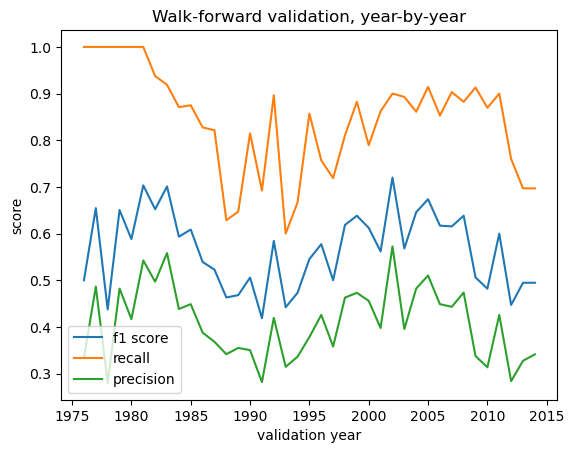

In [51]:
plt.plot([year[0] for year in cv_result['val_year']], cv_result['f1_score'], label='f1 score')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['recall'], label='recall')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['precision'], label='precision')
plt.xlabel("validation year")
plt.ylabel("score")
plt.title('Walk-forward validation, year-by-year')
plt.legend()

<Axes: >

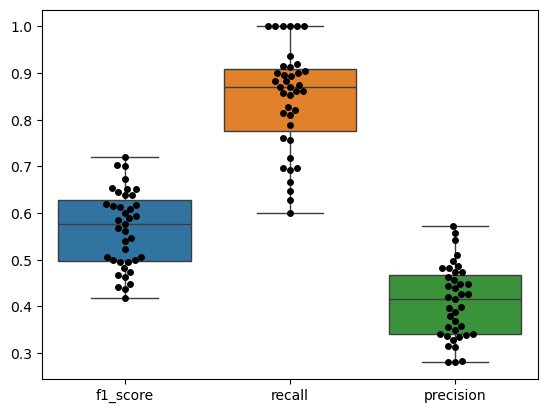

In [52]:
import seaborn as sns


ax = sns.boxplot(data=cv_result[['f1_score', 'recall', 'precision']])

sns.swarmplot(data=cv_result[['f1_score', 'recall', 'precision']], ax=ax, color='black')


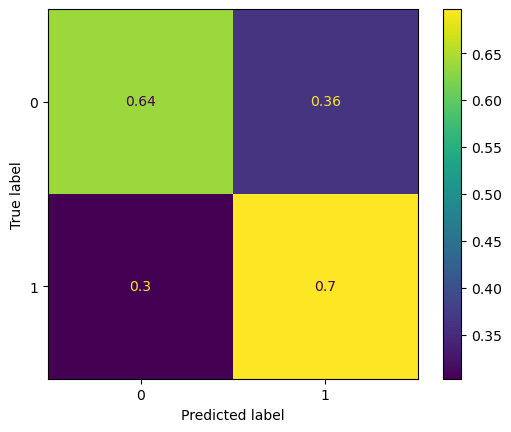

In [53]:
conf = confusion_matrix(book_val['target'], book_val['predicted'], normalize='true')#.ravel().tolist()

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix=conf).plot()


Let us look at the most important features.

In [54]:
feature_names = model.named_steps['preprocess'].get_feature_names_out()

importances = model.named_steps['xgb_rank'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(20))

                                              Feature  Importance
71                                 synopsis__knn_pred    0.415305
0          numerical_scaling__Total_Awards_Previously    0.064296
3      numerical_scaling__years_since_last_nomination    0.046625
2                 numerical_scaling__author_num_books    0.041006
17                onehot__first_publisher_bantambooks    0.035714
29                   onehot__first_publisher_gollancz    0.024932
70        nominee_,similarity__past_winner_similarity    0.022922
6                             bool_to_int__new_author    0.022331
69                 tag_similarity__cohort_similiarity    0.021880
1        numerical_scaling__Author_Age_at_Publication    0.020997
61                    onehot__month_of_publication_06    0.020198
63                    onehot__month_of_publication_08    0.018920
40                  onehot__first_publisher_orbit(us)    0.018696
58                    onehot__month_of_publication_03    0.016802
13        

The fact that these models are so reliant on the # of total awards and the # of years since last nomination implies that they are not good at finding books by authors who have not previously been nominated. Let's see.

In [242]:
identified_noms = book_val[(book_val['target'] == 1) & (book_val['predicted'] == 1)]
unidentified_noms = book_val[(book_val['target'] == 1) & (book_val['predicted'] == 0)]

In [243]:
identified_noms['Total_Awards_Previously'].value_counts()

Total_Awards_Previously
1.0     7
2.0     4
6.0     3
22.0    2
9.0     2
3.0     2
13.0    2
5.0     1
14.0    1
18.0    1
Name: count, dtype: int64

In [244]:
unidentified_noms['Total_Awards_Previously'].value_counts()

Total_Awards_Previously
0.0    14
1.0     5
2.0     2
4.0     1
Name: count, dtype: int64

In [245]:
identified_noms['NomineeBefore'].value_counts()

NomineeBefore
True    25
Name: count, dtype: int64

In [246]:
unidentified_noms['NomineeBefore'].value_counts()

NomineeBefore
False    14
True      8
Name: count, dtype: int64

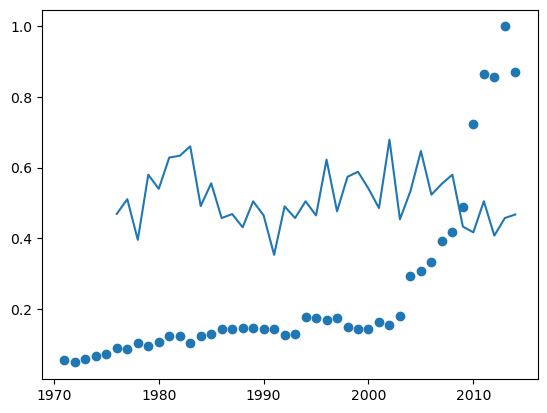

In [251]:
newbie_count = books_tt.groupby('release_year')['new_author'].sum()

years = newbie_count.index.values
values = newbie_count.values

plt.scatter(years, values/np.max(values))
plt.plot([year[0] for year in cv_result['val_year']], cv_result['f1_score'], label='f1 score')


### Improving on New author training

can we change anything about these features to try and improve this?

In [227]:
books_tt_copy = books_tt.copy()

books_tt_copy['author_success_fraction'] = books_tt_copy['Total_Awards_Previously'] / books_tt_copy['author_num_books']

numerical_features = ["Author_Age_at_Publication", 'author_success_fraction', 'publisher_historical_nominations']
categorical_features = ["first_publisher", "month_of_publication"]
mlb_features = ["tags"]
bool_features = ["new_author"]

features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

# for each categorical feature, create one-hot encoding
categorical_pipeline = Pipeline(
    steps=[
        ('solve_nans', SimpleImputer(fill_value='Unknown', strategy='constant')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ] 
)

# numerical features: z-score normalization with the rest of the year.
# turn bool features to int
# calculate similarities
feature_preprocessing = ColumnTransformer(
    transformers=[
        ('numerical_scaling', YearByYearStandardScaler(year_column='release_year', scale_columns=numerical_features), numerical_features + ['release_year']),
        ('bool_to_int', FunctionTransformer(lambda x: x.astype(int), feature_names_out='one-to-one'), bool_features),
        ('onehot', categorical_pipeline, categorical_features),
    ('tag_similarity', YearlyGenreTagScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year']) ,
    ('nominee_similarity', YearlyPastNomineeSimilarityScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year'])    ],
)

In [228]:
model =  Pipeline(steps=[
        ('preprocess', feature_preprocessing),
        ('xgb_rank', xgb.XGBRanker(
    tree_method="hist",
    objective="rank:ndcg",
    eval_metric="ndcg@60", # because each year has < 60 nominees, we care most about ranking those.
    lambdarank_pair_method="topk",

    lambdarank_num_pair_per_sample=60, 
    
    max_depth=4,                       
    learning_rate=0.05,
    n_estimators=300,                  
    colsample_bytree=0.7,              
    subsample=0.8
))
])

windows = walk_forward(books_tt_copy)

In [ ]:
cv_data = []

for num, fold in enumerate(windows):
    book_train = fold[0]
    book_val = fold[1]

    book_train = book_train.copy()
    book_val = book_val.copy()
    year = book_val['release_year'].mode()

    model.fit(
                book_train[features],
                book_train['target'],
                xgb_rank__qid=book_train['release_year'],
            )
    
    ypred = model.predict(book_val[features])
    book_val['predicted_score'] = ypred

    book_val['rank_within_year'] = book_val.groupby('release_year')[o. Interestingly, in t'predicted_score'].rank(
            method='first', 
            ascending=False
        )
    
    book_val['predicted'] = (book_val['rank_within_year'] <= num_finalists).astype(int)

    f1score = f1_score(book_val['target'], book_val['predicted'].values)
    recall = recall_score(book_val['target'], book_val['predicted'].values)

    cv_data.append({'fold': num, "val_year": year.values, 'f1_score': f1score, 'recall': recall})
    print(num)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38


In [230]:
cv_result = pd.DataFrame(cv_data)
print("Mean f1 score across folds: ", cv_result['f1_score'].mean())
print("STD of f1 score across folds: ", cv_result['f1_score'].std())

Mean f1 score across folds:  0.5129346175634971
STD of f1 score across folds:  0.07797872684601732


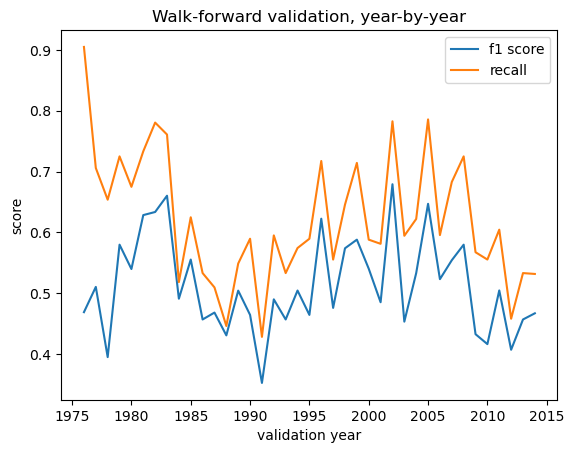

In [231]:
plt.plot([year[0] for year in cv_result['val_year']], cv_result['f1_score'], label='f1 score')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['recall'], label='recall')
plt.xlabel("validation year")
plt.ylabel("score")
plt.title('Walk-forward validation, year-by-year')
plt.legend()

<Axes: >

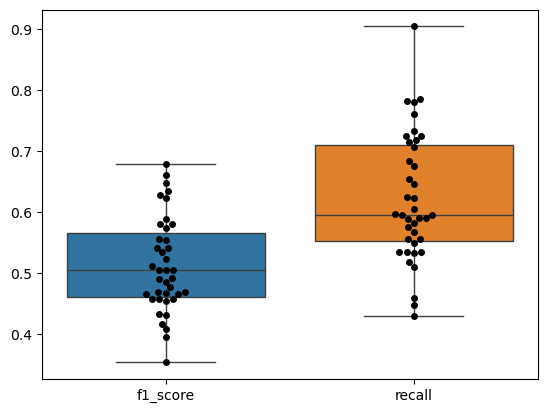

In [234]:
ax = sns.boxplot(data=cv_result[['f1_score', 'recall']])

sns.swarmplot(data=cv_result[['f1_score', 'recall']], ax=ax, color='black')


In [235]:
feature_names = model.named_steps['preprocess'].get_feature_names_out()

importances = model.named_steps['xgb_rank'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(20))

                                              Feature  Importance
1          numerical_scaling__author_success_fraction    0.363921
78         nominee_similarity__past_winner_similarity    0.098906
54                     onehot__first_publisher_signet    0.049835
2   numerical_scaling__publisher_historical_nomina...    0.043160
15                onehot__first_publisher_bantambooks    0.038241
77                 tag_similarity__cohort_similiarity    0.031306
29                   onehot__first_publisher_gollancz    0.029193
57           onehot__first_publisher_st.martin'spress    0.024495
45                onehot__first_publisher_pocketbooks    0.021919
43                  onehot__first_publisher_orbit(us)    0.019734
0        numerical_scaling__Author_Age_at_Publication    0.019496
13                  onehot__first_publisher_baenbooks    0.018383
23                        onehot__first_publisher_daw    0.017850
42                      onehot__first_publisher_orbit    0.015975
72        